<a href="https://colab.research.google.com/github/Palak1608/Data-Science-Lab-Work/blob/main/Advanced_Project/sentiment_analysis_social_media.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Sentiment Analysis on IMDB Reviews using Machine Learning

In [ ]:
import pandas as pd

df = pd.read_csv("IMDB Dataset.csv", engine="python")
df.head()

,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   review     50000 non-null  object
 1   sentiment  50000 non-null  object
dtypes: object(2)
memory usage: 781.4+ KB


In [ ]:
df["sentiment"].value_counts()

,count
sentiment,
positive,25000
negative,25000


## Dataset Overview
The dataset contains 50,000 movie reviews labeled as positive and negative sentiments.

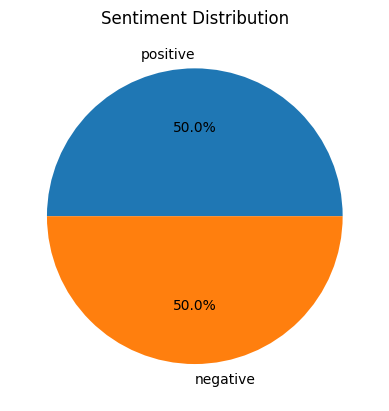

In [ ]:
import matplotlib.pyplot as plt

df["sentiment"].value_counts().plot(kind="pie", autopct="%1.1f%%")
plt.title("Sentiment Distribution")
plt.ylabel("")
plt.show()

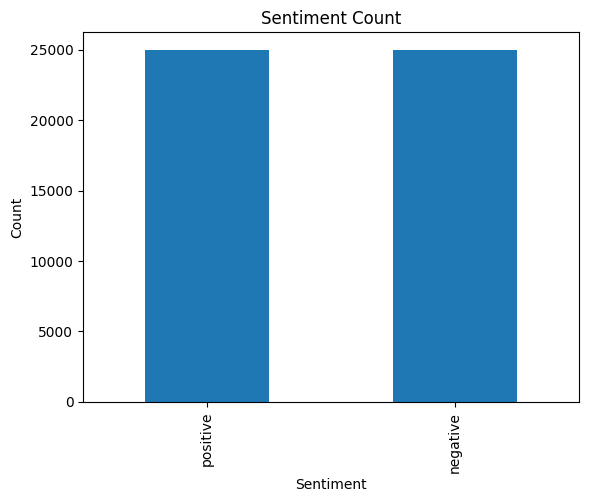

In [ ]:
df["sentiment"].value_counts().plot(kind="bar")
plt.title("Sentiment Count")
plt.xlabel("Sentiment")
plt.ylabel("Count")
plt.show()

## Data Preprocessing
Cleaning text data by removing special characters and converting to lowercase.

In [ ]:
import re

def clean_text(text):
    text = re.sub(r"[^a-zA-Z]", " ", text)
    text = text.lower()
    return text

df["review"] = df["review"].apply(clean_text)

## Feature Extraction using TF-IDF

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(max_features=5000)

X = vectorizer.fit_transform(df["review"])
y = df["sentiment"]

In [ ]:
feature_names = vectorizer.get_feature_names_out()
print(feature_names[:20])

['aaron' 'abandoned' 'abc' 'abilities' 'ability' 'able' 'about' 'above'
 'absence' 'absent' 'absolute' 'absolutely' 'absurd' 'abuse' 'abused'
 'abusive' 'abysmal' 'academy' 'accent' 'accents']


In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

## Model Training
Logistic Regression is used to classify movie reviews into positive and negative sentiments.

In [ ]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

LogisticRegression(max_iter=1000)

In [ ]:
from sklearn.metrics import accuracy_score

y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 0.8945


## Model Evaluation
The confusion matrix shows how well the model predicts positive and negative sentiments.

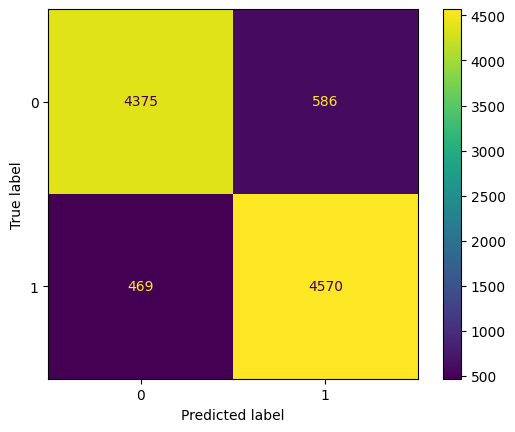

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()

## Predictions
The model is tested on new sample reviews to predict sentiment.

In [ ]:
samples = [
    "This movie was amazing",
    "Worst movie ever",
    "It was okay"
]

sample_vec = vectorizer.transform(samples)

for review, pred in zip(samples, model.predict(sample_vec)):
    print(review, "->", pred)

This movie was amazing -> positive
Worst movie ever -> negative
It was okay -> negative


## Insights

- The dataset contains 50,000 movie reviews labeled as positive and negative.

- Text preprocessing improves model performance by removing noise.

- TF-IDF helps convert text into numerical features based on word importance.

- Logistic Regression achieved approximately 89% accuracy, showing strong performance.

- The confusion matrix indicates that the model can effectively distinguish between sentiments.

- This model can be used in real-world applications like sentiment analysis of reviews, social media, and customer feedback.

- The model demonstrates how natural language processing can be applied to extract meaningful insights from unstructured text data.

- Although the problem statement suggests using social media data, this project uses movie reviews as a form of textual sentiment data. The same techniques can be applied to social media posts for real-world sentiment analysis.